In [1]:
# import libraries, all used 
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# import EMBER dataset
DATA_DIR = "/Users/theaurilios/srp/EMBER2024/EMBER24_Data/"

In [2]:
# Getting all the valid test jsonl files from datset
jsonl_files = [
    os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) 
    if "test" in f and f.endswith(".jsonl")
]

print("Shape of EMBER2024:")
print(f"Found {len(jsonl_files)} JSONL chunks.")

X_list = []
y_list = []
MAX_SAMPLES = 20000

# Had to parse the files directly, avoiding errors
for file_path in jsonl_files:
    if len(X_list) >= MAX_SAMPLES:
        break
        
    print(f"Processing chunk: {os.path.basename(file_path)}...")
    with open(file_path, 'r') as f:
        for line in f:
            if len(X_list) >= MAX_SAMPLES:
                break
            try:
                obj = json.loads(line)
                gen = obj['general']
                features = [
                    gen.get('size', 0),
                    gen.get('has_debug', 0),
                    gen.get('has_exports', 0),
                    gen.get('has_imports', 0),
                    gen.get('has_relocations', 0),
                    gen.get('has_resources', 0),
                    gen.get('has_signature', 0),
                    gen.get('has_tls', 0),
                    gen.get('symbols_in_export', 0),
                    gen.get('symbols_in_import', 0)
                ]
                X_list.append(features)
                y_list.append(obj['label'])
            except (json.JSONDecodeError, KeyError):
                continue

X_subset = np.array(X_list, dtype=np.float32)
y_subset = np.array(y_list, dtype=np.int32)
print(f"\nArray Shape: {X_subset.shape}")

Shape of EMBER2024:
Found 36 JSONL chunks.
Processing chunk: 2024-10-13_2024-10-19_Dot_Net_test.jsonl...
Processing chunk: 2024-10-27_2024-11-02_Win32_test.jsonl...

Array Shape: (20000, 10)


In [3]:
# EMBER's 10 overlapping features
ember_features = [
    'size', 'has_debug', 'has_exports', 'has_imports', 'has_relocations',
    'has_resources', 'has_signature', 'has_tls', 'symbols_in_export', 'symbols_in_import'
]

# Mapping vectors to dataframe, needed for alignment (error fixing)
X_df = pd.DataFrame(X_subset, columns=ember_features)
y_series = pd.Series(y_subset, name='class')

print("Shape configurations:")
print(f"x shape: {X_df.shape}")
print(f"y shape: {y_series.shape}")

print("\nLabel head preview:")
print(y_series.head())

Shape configurations:
x shape: (20000, 10)
y shape: (20000,)

Label head preview:
0    1
1    0
2    1
3    1
4    1
Name: class, dtype: int32


In [4]:
from sklearn.model_selection import train_test_split

# Splitting into 200 training and 50 testing samples
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_series, train_size=200, test_size=50, random_state=10, stratify=y_series
)

print("Split Data:")
print(f"len(X_train): {len(X_train)}")
print(f"len(X_test):  {len(X_test)}")
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape:  {X_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape:  {y_test.shape}")

Split Data:
len(X_train): 200
len(X_test):  50
X_train.shape: (200, 10)
X_test.shape:  (50, 10)
y_train.shape: (200,)
y_test.shape:  (50,)


In [5]:
print("Length of Split Data:")
print(f"{len(X_df)} - number of elements in the entire dataset.")
print(f"{len(X_train)} - number of training elements.")
print(f"{len(X_test)} - number of testing elements.")
print(f"{len(X_train) + len(X_test)} - sum of training and testing elements.")

Length of Split Data:
20000 - number of elements in the entire dataset.
200 - number of training elements.
50 - number of testing elements.
250 - sum of training and testing elements.


In [6]:
print("Training Summary")
display(X_train.describe())

print("\nTesting Summary")
display(X_test.describe())

Training Summary


,size,has_debug,has_exports,has_imports,has_relocations,has_resources,has_signature,has_tls,symbols_in_export,symbols_in_import
count,2.000000e+02,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0
mean,1.874756e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,4.292975e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,3.072000e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,4.915200e+04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,2.174120e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,1.551104e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,3.199127e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Testing Summary


,size,has_debug,has_exports,has_imports,has_relocations,has_resources,has_signature,has_tls,symbols_in_export,symbols_in_import
count,50.00,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0
mean,1766309.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,4112501.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,3072.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,31896.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,193280.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,1262656.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,23651840.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
print("Entire EMBER2024 data summary")
# needed to join features and class show the whole table 
full_subset_df = X_df.join(y_series)
with pd.option_context('display.max_columns', None):
    display(full_subset_df.describe())

Entire EMBER2024 data summary


,size,has_debug,has_exports,has_imports,has_relocations,has_resources,has_signature,has_tls,symbols_in_export,symbols_in_import,class
count,20000.00,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.000000
mean,2133108.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.470250
std,7699309.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.499127
min,512.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,40522.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
50%,163840.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
75%,974336.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
max,99772624.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000


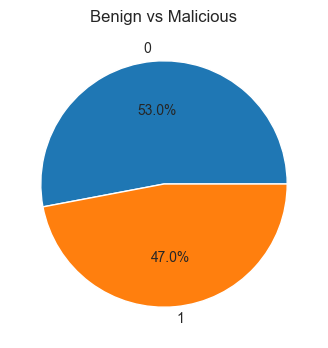

In [8]:
# Seaborn benign vs malicious pie chart
sns.set_style('whitegrid') 
plt.figure(figsize=(6, 4)) 
plt.pie(y_series.value_counts(), labels=y_series.value_counts().index, autopct='%1.1f%%')
plt.title('Benign vs Malicious')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

# StandardScaler forr skewed data
scaler = StandardScaler()
Xtrainscaled = scaler.fit_transform(X_train)
Xtestscaled = scaler.transform(X_test)

print("Feature scaling done")
print(f"Scaled Train Bounds: Min={Xtrainscaled.min():.1f}, Max={Xtrainscaled.max():.1f}")

Feature scaling done
Scaled Train Bounds: Min=-0.4, Max=7.0


In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

linear_svm = SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42)
linear_svm.fit(Xtrainscaled, y_train)

# Testing
preds = linear_svm.predict(Xtestscaled)
acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, preds)

# Report
print("          CLASSICAL SVM RESULTS")
print(f"Overall Accuracy: {acc:.4f}")

print("\nClassification Matrix Detail:")
print(classification_report(y_test, preds, target_names=['Benign (0)', 'Malware (1)']))

          CLASSICAL SVM RESULTS
Overall Accuracy: 0.5800

Classification Matrix Detail:
              precision    recall  f1-score   support

  Benign (0)       0.56      0.96      0.70        26
 Malware (1)       0.80      0.17      0.28        24

    accuracy                           0.58        50
   macro avg       0.68      0.56      0.49        50
weighted avg       0.67      0.58      0.50        50

